In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os



import kagglehub


In [4]:
import torch

In [5]:
torch.cuda.is_available()

True

In [7]:
!pip install segmentation-models-pytorch -q

**WITHOUT VALIDATION DATASET**

In [8]:
img_dir  = "/kaggle/input/datasets/nadeef123/cropped-tumor/cropped/images"
mask_dir = "/kaggle/input/datasets/nadeef123/cropped-tumor/cropped/masks"

In [9]:
import os, cv2, torch
from torch.utils.data import Dataset, DataLoader

class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.imgs = sorted(os.listdir(img_dir))
        self.img_dir = img_dir
        self.mask_dir = mask_dir

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = cv2.imread(os.path.join(self.img_dir, self.imgs[idx]))
        mask = cv2.imread(os.path.join(self.mask_dir, self.imgs[idx]), 0)

        img = cv2.resize(img, (256, 256)) / 255.0
        mask = cv2.resize(mask, (256, 256)) / 255.0

        img = torch.tensor(img).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

dataset = SegDataset(img_dir, mask_dir)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [11]:
import segmentation_models_pytorch as smp

model1 = smp.Unet("resnet34", encoder_weights="imagenet", in_channels=3, classes=1)
model2 = smp.UnetPlusPlus("resnet34", encoder_weights="imagenet", in_channels=3, classes=1)
model3 = smp.Unet("resnet34", encoder_weights="imagenet", in_channels=3, classes=1, decoder_attention_type="scse")

model1.to(device)
model2.to(device)
model3.to(device)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [12]:
import torch.nn as nn

bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-5
    return 1 - ((2*(pred*target).sum()+smooth) / (pred.sum()+target.sum()+smooth))

def loss_fn(pred, target):
    return bce(pred, target) + dice_loss(pred, target)

In [13]:
def train_model(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    losses, dices = [], []

    for epoch in range(10):
        model.train()
        total_loss, total_dice = 0, 0

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            preds = model(imgs)
            loss = loss_fn(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            pred_bin = (torch.sigmoid(preds) > 0.5).float()
            dice = (2*(pred_bin*masks).sum())/(pred_bin.sum()+masks.sum()+1e-5)
            total_dice += dice.item()

        losses.append(total_loss/len(train_loader))
        dices.append(total_dice/len(train_loader))

        print(f"Epoch {epoch} | Loss {losses[-1]:.4f} | Dice {dices[-1]:.4f}")

    return model, losses, dices

In [14]:
model1, loss1, dice1 = train_model(model1)
model2, loss2, dice2 = train_model(model2)
model3, loss3, dice3 = train_model(model3)

Epoch 0 | Loss 0.4968 | Dice 0.8943
Epoch 1 | Loss 0.4378 | Dice 0.9071
Epoch 2 | Loss 0.4131 | Dice 0.9129
Epoch 3 | Loss 0.3970 | Dice 0.9163
Epoch 4 | Loss 0.3868 | Dice 0.9187
Epoch 5 | Loss 0.3753 | Dice 0.9208
Epoch 6 | Loss 0.3650 | Dice 0.9229
Epoch 7 | Loss 0.3600 | Dice 0.9235
Epoch 8 | Loss 0.3491 | Dice 0.9255
Epoch 9 | Loss 0.3348 | Dice 0.9280
Epoch 0 | Loss 0.4879 | Dice 0.8967
Epoch 1 | Loss 0.4310 | Dice 0.9093
Epoch 2 | Loss 0.4149 | Dice 0.9127
Epoch 3 | Loss 0.4022 | Dice 0.9158
Epoch 4 | Loss 0.3875 | Dice 0.9185
Epoch 5 | Loss 0.3782 | Dice 0.9204
Epoch 6 | Loss 0.3704 | Dice 0.9218
Epoch 7 | Loss 0.3568 | Dice 0.9241
Epoch 8 | Loss 0.3482 | Dice 0.9261
Epoch 9 | Loss 0.3453 | Dice 0.9265
Epoch 0 | Loss 0.4954 | Dice 0.8945
Epoch 1 | Loss 0.4340 | Dice 0.9081
Epoch 2 | Loss 0.4119 | Dice 0.9129
Epoch 3 | Loss 0.4017 | Dice 0.9152
Epoch 4 | Loss 0.3905 | Dice 0.9173
Epoch 5 | Loss 0.3807 | Dice 0.9190
Epoch 6 | Loss 0.3685 | Dice 0.9216
Epoch 7 | Loss 0.3630 | Dice

In [15]:
def ensemble_predict(models, img):
    preds = []
    for m in models:
        m.eval()
        with torch.no_grad():
            p = torch.sigmoid(m(img.unsqueeze(0).to(device)))
            preds.append(p)
    return torch.mean(torch.stack(preds), dim=0)

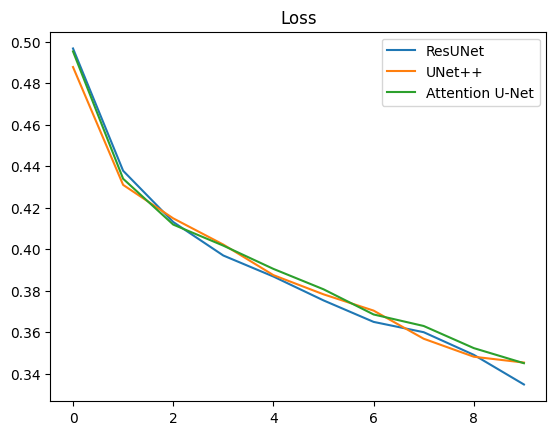

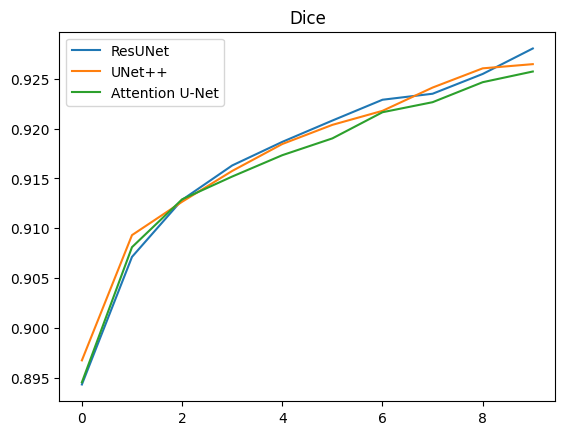

In [16]:
import matplotlib.pyplot as plt

plt.plot(loss1, label="ResUNet")
plt.plot(loss2, label="UNet++")
plt.plot(loss3, label="Attention U-Net")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(dice1, label="ResUNet")
plt.plot(dice2, label="UNet++")
plt.plot(dice3, label="Attention U-Net")
plt.legend()
plt.title("Dice")
plt.show()

**AFTER SETTING 20% IMAGES FOR VALIDATION**

In [17]:
import os, cv2, torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


class MRIDataset(Dataset):
    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv2.imread(self.images[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.masks[idx], 0)

        img = cv2.resize(img, (256, 256))
        mask = cv2.resize(mask, (256, 256))

        mask = mask / 255.0
        mask = np.expand_dims(mask, 0)

        img = img / 255.0
        img = np.transpose(img, (2, 0, 1))

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

image_dir = "/kaggle/input/datasets/nadeef123/cropped-tumor/cropped/images"
mask_dir  = "/kaggle/input/datasets/nadeef123/cropped-tumor/cropped/masks"

images = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir)])
masks  = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

train_loader = DataLoader(MRIDataset(train_imgs, train_masks), batch_size=8, shuffle=True)
val_loader   = DataLoader(MRIDataset(val_imgs, val_masks), batch_size=8)

In [19]:
import segmentation_models_pytorch as smp

device = "cuda" if torch.cuda.is_available() else "cpu"

resunet = smp.Unet("resnet34", encoder_weights="imagenet", classes=1).to(device)

att_unet = smp.Unet(
    "resnet34",
    encoder_weights="imagenet",
    decoder_attention_type="scse",
    classes=1
).to(device)

unetpp = smp.UnetPlusPlus("resnet34", encoder_weights="imagenet", classes=1).to(device)

In [20]:
criterion = smp.losses.DiceLoss(mode='binary')

opt_resunet = torch.optim.Adam(resunet.parameters(), lr=1e-4)
opt_att     = torch.optim.Adam(att_unet.parameters(), lr=1e-4)
opt_unetpp  = torch.optim.Adam(unetpp.parameters(), lr=1e-4)


def dice_score(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()
    intersection = (preds * targets).sum()
    return (2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)

In [23]:
def train(model, optimizer, epochs=10):
    train_losses, val_losses, dices = [], [], []

    for epoch in range(epochs):
        model.train()
        tl = 0

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, masks)
            loss.backward()
            optimizer.step()

            tl += loss.item()

        model.eval()
        vl, d = 0, 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                out = model(imgs)

                vl += criterion(out, masks).item()
                d += dice_score(out, masks).item()

        tl /= len(train_loader)
        vl /= len(val_loader)
        d  /= len(val_loader)

        train_losses.append(tl)
        val_losses.append(vl)
        dices.append(d)

        print(f"Epoch {epoch+1} | Train {tl:.4f} | Val {vl:.4f} | Dice {d:.4f}")

    return train_losses, val_losses, dices

In [24]:
res_hist = train(resunet, opt_resunet)
att_hist = train(att_unet, opt_att)
unetpp_hist = train(unetpp, opt_unetpp)

Epoch 1 | Train 0.1842 | Val 0.1213 | Dice 0.9130
Epoch 2 | Train 0.1028 | Val 0.0961 | Dice 0.9173
Epoch 3 | Train 0.0852 | Val 0.0898 | Dice 0.9170
Epoch 4 | Train 0.0762 | Val 0.0850 | Dice 0.9193
Epoch 5 | Train 0.0691 | Val 0.0849 | Dice 0.9181
Epoch 6 | Train 0.0650 | Val 0.0826 | Dice 0.9191
Epoch 7 | Train 0.0617 | Val 0.0794 | Dice 0.9212
Epoch 8 | Train 0.0573 | Val 0.0815 | Dice 0.9189
Epoch 9 | Train 0.0515 | Val 0.0783 | Dice 0.9219
Epoch 10 | Train 0.0478 | Val 0.0763 | Dice 0.9237
Epoch 1 | Train 0.1323 | Val 0.1002 | Dice 0.9109
Epoch 2 | Train 0.0887 | Val 0.0879 | Dice 0.9155
Epoch 3 | Train 0.0787 | Val 0.0834 | Dice 0.9178
Epoch 4 | Train 0.0725 | Val 0.0779 | Dice 0.9227
Epoch 5 | Train 0.0668 | Val 0.0788 | Dice 0.9212
Epoch 6 | Train 0.0627 | Val 0.0782 | Dice 0.9217
Epoch 7 | Train 0.0605 | Val 0.0808 | Dice 0.9190
Epoch 8 | Train 0.0575 | Val 0.0782 | Dice 0.9214
Epoch 9 | Train 0.0528 | Val 0.0808 | Dice 0.9189
Epoch 10 | Train 0.0539 | Val 0.0815 | Dice 0.918

In [25]:
def ensemble_predict(img):
    img = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        p1 = torch.sigmoid(resunet(img))
        p2 = torch.sigmoid(att_unet(img))
        p3 = torch.sigmoid(unetpp(img))

    avg = (p1 + p2 + p3) / 3
    return (avg > 0.5).float()

In [26]:
def plot_history(history, title):
    train_loss, val_loss, dice = history

    plt.figure()
    plt.plot(train_loss, label="Train Loss")
    plt.plot(val_loss, label="Val Loss")
    plt.title(title)
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(dice, label="Dice Score")
    plt.title(title + " Dice")
    plt.legend()
    plt.show()

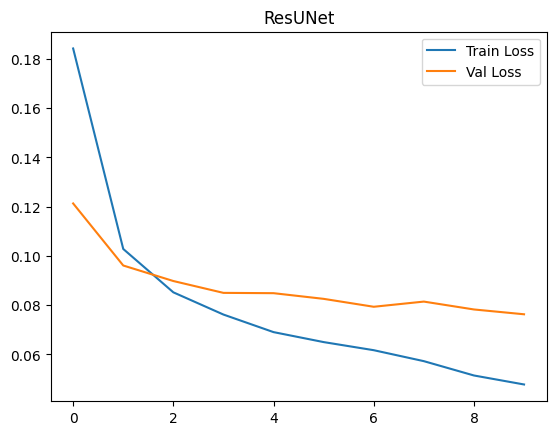

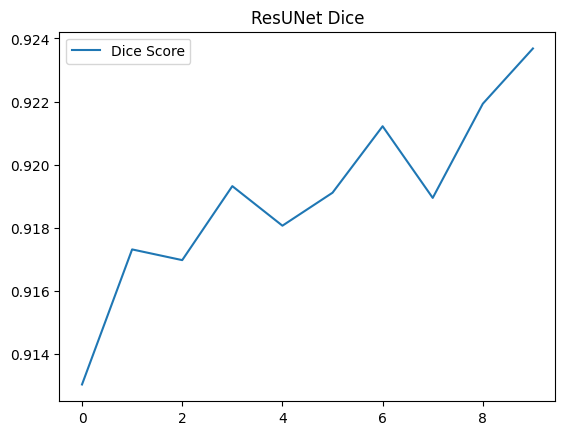

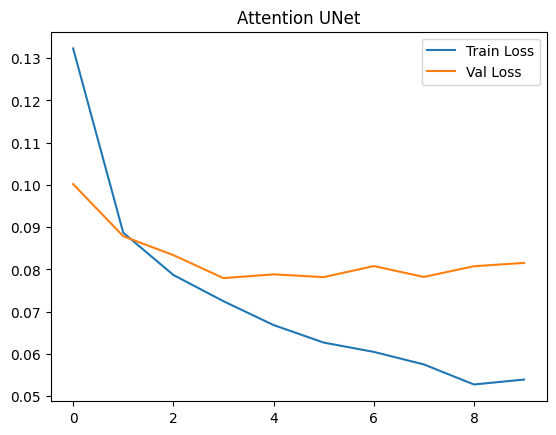

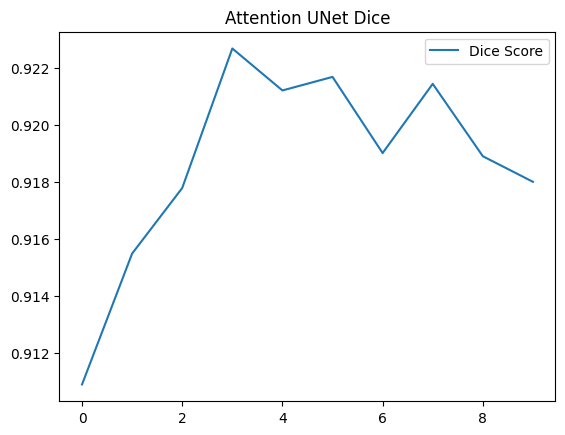

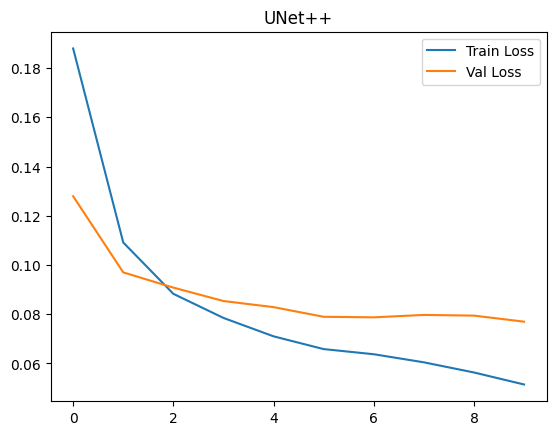

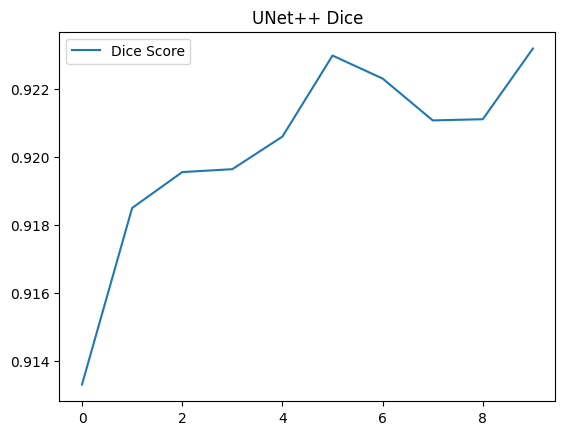

In [27]:
plot_history(res_hist, "ResUNet")
plot_history(att_hist, "Attention UNet")
plot_history(unetpp_hist, "UNet++")

In [47]:
import cv2
import numpy as np

img_path = "/kaggle/input/datasets/nadeef123/cropped-tumor/cropped/images/20.png_0.png"

image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_resized = cv2.resize(image_rgb, (256, 256))

img_tensor = image_resized / 255.0
img_tensor = np.transpose(img_tensor, (2, 0, 1))

img_tensor = torch.tensor(
    img_tensor,
    dtype=torch.float32
).unsqueeze(0).to(device)

In [48]:
with torch.no_grad():

    p1 = torch.sigmoid(resunet(img_tensor))
    p2 = torch.sigmoid(att_unet(img_tensor))
    p3 = torch.sigmoid(unetpp(img_tensor))

    ensemble = (p1 + p2 + p3) / 3

mask = (ensemble > 0.5).float()
mask = mask.squeeze().cpu().numpy().astype(np.uint8)

In [49]:
tumor_pixels = np.sum(mask)

if tumor_pixels > 0:
    print("Tumor Detected")
else:
    print("No Tumor Detected")

Tumor Detected


In [50]:
area_pixels = np.sum(mask)

print("Tumor Area (pixels):", area_pixels)

Tumor Area (pixels): 46860


In [51]:
coords = np.column_stack(np.where(mask > 0))

if len(coords) > 0:

    centroid_y = int(np.mean(coords[:,0]))
    centroid_x = int(np.mean(coords[:,1]))

    print("Centroid X:", centroid_x)
    print("Centroid Y:", centroid_y)

Centroid X: 116
Centroid Y: 115


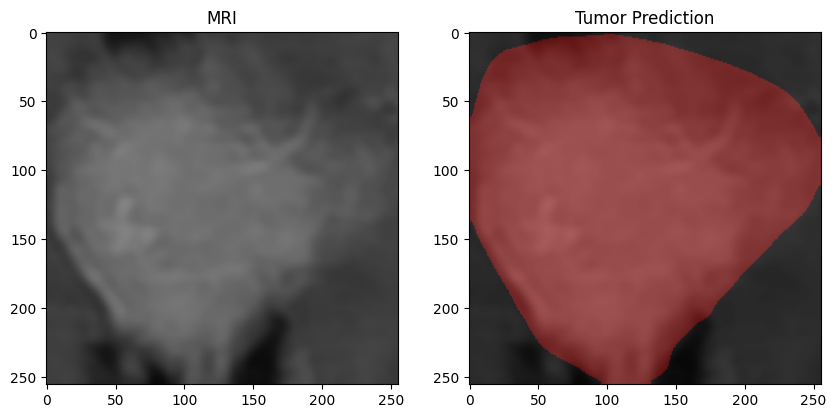

In [52]:
mask_color = np.zeros_like(image_resized)

mask_color[:,:,0] = mask * 255

overlay = cv2.addWeighted(
    image_resized,
    0.7,
    mask_color,
    0.3,
    0
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_resized)
plt.title("MRI")

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title("Tumor Prediction")

plt.show()


In [53]:
cv2.imwrite('resized.jpg', image_resized)
cv2.imwrite('overlay.jpg',overlay)

True

In [56]:
import torch


# Save the weights for each model
torch.save(resunet.state_dict(), "resunet_weights.pt")
torch.save(att_unet.state_dict(), "attention_unet_weights.pt")
torch.save(unetpp.state_dict(), "unet_plus_plus_weights.pt")

print("All model weights saved successfully!")


All model weights saved successfully!
